# Emotional Manipulation Detection
## Moral Foundation Trajectory Analysis with eMFD + VADER + Stylistic Features

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# PHASE 0 — ENVIRONMENT SETUP
# ─────────────────────────────────────────────────────────────────────────────
# Uncomment to install required packages on first run:
# %pip install -q https://github.com/medianeuroscience/emfdscore/archive/master.zip
# !python -m spacy download en_core_web_sm

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

## Phase 1 — Dataset Collection & Preparation
Two public datasets are combined into a single binary corpus:
- **Tweet Emotions** (Twitter/Kaggle): emotional vs. neutral tweets
- **Propaganda Dataset** (SemEval/NLP4IF): propaganda vs. non-propaganda text

Label schema: `1 = Manipulative` (emotional/propaganda), `0 = Neutral`

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# PHASE 1A — LOAD & LABEL DATASETS
# ─────────────────────────────────────────────────────────────────────────────
propaganda_df = pd.read_csv('propaganda_dataset.csv')
tweets_df     = pd.read_csv('tweet_emotions.csv')

# Binary label encoding
# Tweets: neutral/empty → 0  |  worry/happiness/sadness/love → 1
tweets_df['label'] = tweets_df['sentiment'].apply(
    lambda s: False if s in ('neutral', 'empty') else True
)
propaganda_df['label'] = propaganda_df['label'].astype(bool)

# Unify schema & concatenate
tweets_df = tweets_df[['label', 'content']].rename(columns={'content': 'text'})
df = pd.concat([tweets_df, propaganda_df[['label', 'text']]], ignore_index=True)

print(f"Combined corpus : {len(df):,} samples")
print(f"Label distribution:\n{df['label'].value_counts()}")

Combined corpus : 50,000 samples
Label distribution:
label
True     35535
False    14465
Name: count, dtype: int64


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# PHASE 1B — CLASS BALANCING (Undersampling)
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.utils import resample

df_majority = df[df['label'] == True]
df_minority = df[df['label'] == False]

RATIO = 1.1  # majority:minority ratio after undersampling
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=int(len(df_minority) * RATIO),
    random_state=42
)

df_balanced = (
    pd.concat([df_majority_downsampled, df_minority])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)
df_full = df.copy()

print("─── Balanced Dataset ───────────────────────────")
print(df_balanced['label'].value_counts())
print(f"Balanced training samples : {len(df_balanced):,}")
print(f"Full corpus samples       : {len(df_full):,}")

─── Balanced Dataset ───────────────────────────
label
True     15911
False    14465
Name: count, dtype: int64
Balanced training samples : 30,376
Full corpus samples       : 50,000


## Phase 2A — Sentence Segmentation & eMFD Moral Scoring
Each document is split into sentences using spaCy. Sentences are scored with
the **extended Moral Foundations Dictionary (eMFD)**, producing 10-dimensional
probability vectors across five moral foundations (virtue + vice each).

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# PHASE 2A — SENTENCE SEGMENTATION
# ─────────────────────────────────────────────────────────────────────────────
import spacy
from emfdscore.scoring import score_docs

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    os.system("python -m spacy download en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

def prepare_sentence_pipeline(df, text_column='text'):
    """Split each document into sentences; discard very short fragments."""
    sentence_data = []
    for idx, row in df.iterrows():
        doc = nlp(row[text_column])
        for i, sent in enumerate(doc.sents):
            text = sent.text.strip()
            if len(text) > 20:
                sentence_data.append({
                    'doc_id'  : idx,
                    'sent_seq': i,
                    'text'    : text
                })
    return pd.DataFrame(sentence_data)

sentence_df = prepare_sentence_pipeline(df_balanced, text_column='text')
print(f"Sentence corpus : {len(sentence_df):,} sentences from {df_balanced.shape[0]:,} documents")

Sentence corpus : 37,343 sentences from 30,376 documents


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# PHASE 2A — eMFD MORAL SCORING
# ─────────────────────────────────────────────────────────────────────────────
text_df = sentence_df[['text']]

scored_results = score_docs(
    text_df,
    dic_type    = 'emfd',
    prob_map    = 'all',
    score_type  = 'bow',
    out_metrics = 'vice-virtue',
    num_docs    = len(sentence_df)
)

scored_df = pd.concat([sentence_df[['doc_id', 'sent_seq']], scored_results], axis=1)
print(f"Scored sentence matrix : {scored_df.shape}")
print(f"eMFD columns           : {[c for c in scored_results.columns]}")

Processed: 0   0% |                      | Elapsed Time: 0:00:00 ETA:  --:--:--
Processed: 20   0% |                     | Elapsed Time: 0:00:00 ETA:   0:03:12
Processed: 41   0% |                     | Elapsed Time: 0:00:00 ETA:   0:03:07
Processed: 61   0% |                     | Elapsed Time: 0:00:00 ETA:   0:03:08
Processed: 84   0% |                     | Elapsed Time: 0:00:00 ETA:   0:03:01
Processed: 102   0% |                    | Elapsed Time: 0:00:00 ETA:   0:03:07
Processed: 123   0% |                    | Elapsed Time: 0:00:00 ETA:   0:03:05
Processed: 145   0% |                    | Elapsed Time: 0:00:00 ETA:   0:03:02
Processed: 165   0% |                    | Elapsed Time: 0:00:00 ETA:   0:03:03
Processed: 186   0% |                    | Elapsed Time: 0:00:00 ETA:   0:03:03
Processed: 209   0% |                    | Elapsed Time: 0:00:01 ETA:   0:03:01
Processed: 231   0% |                    | Elapsed Time: 0:00:01 ETA:   0:03:00
Processed: 254   0% |                   

Scored sentence matrix : (37343, 14)
eMFD columns           : ['care.virtue', 'fairness.virtue', 'loyalty.virtue', 'authority.virtue', 'sanctity.virtue', 'care.vice', 'fairness.vice', 'loyalty.vice', 'authority.vice', 'sanctity.vice', 'moral_nonmoral_ratio', 'f_var']


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# PHASE 2B — DYNAMIC MORAL TRAJECTORY ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────
from scipy.stats import entropy, linregress

def analyze_manipulation(scored_df):
    """
    Compute document-level moral trajectory features from sentence-level eMFD scores.

    Feature groups:
      [1]  Core density & volatility     (avg, peak, std of moral intensity)
      [2]  Initial hook density          (moral loading in first 2 sentences)
      [3]  Final escalation              (moral loading in last 2 sentences)
      [4]  Escalation delta              (tail − hook)
      [5]  Switching rate                (dominant-frame changes per sentence)
      [6]  Moral entropy                 (distribution spread across foundations)
      [7]  Instability index             (volatility × switching interaction)
      [8]  Vice dominance ratio          (fraction of vice-heavy sentences)
      [9]  Moral trajectory slope        (linear trend of intensity over time)
      [10] Vice/virtue ratio volatility  (std of vice/virtue ratio)
      [11] Peak-to-average ratio         (moral peakedness)
      [12] Per-foundation features       (5 foundations × 3 stats = 15 features)
    """
    foundation_cols = [c for c in scored_df.columns if '.virtue' in c or '.vice' in c]
    foundations     = list({c.rsplit('.', 1)[0] for c in foundation_cols})

    scored_df = scored_df.copy()

    # Row-level scalars
    scored_df['intensity']         = scored_df[foundation_cols].sum(axis=1)
    scored_df['vice_sum']          = scored_df[[c for c in foundation_cols if '.vice'   in c]].sum(axis=1)
    scored_df['virtue_sum']        = scored_df[[c for c in foundation_cols if '.virtue' in c]].sum(axis=1)
    scored_df['vice_virtue_ratio'] = scored_df['vice_sum'] / (scored_df['virtue_sum'] + 1e-9)
    scored_df['dominant_frame']    = scored_df[foundation_cols].idxmax(axis=1)
    scored_df['is_vice_dominant']  = (scored_df['vice_sum'] > scored_df['virtue_sum']).astype(int)

    grouped = scored_df.groupby('doc_id')
    cumcnt  = grouped.cumcount()

    # [1] Core density & volatility
    results = grouped['intensity'].agg(
        avg_moral_density  = 'mean',
        peak_moral_density = 'max',
        tone_volatility    = 'std',
        n_sentences        = 'count'
    ).fillna(0)

    # [2] Initial hook (first 2 sentences)
    first_two = scored_df[cumcnt < 2].groupby('doc_id')['intensity'].mean()
    results['initial_hook_density'] = first_two.reindex(results.index).fillna(results['avg_moral_density'])

    # [3] Final escalation (last 2 sentences)
    rev_cnt   = grouped.cumcount(ascending=False)
    last_two  = scored_df[rev_cnt < 2].groupby('doc_id')['intensity'].mean()
    results['final_escalation'] = last_two.reindex(results.index).fillna(results['avg_moral_density'])

    # [4] Escalation delta (tail − hook)
    results['escalation_delta'] = results['final_escalation'] - results['initial_hook_density']

    # [5] Switching rate (dominant frame changes per sentence gap)
    is_switch  = scored_df['dominant_frame'] != grouped['dominant_frame'].shift(1)
    is_switch &= cumcnt > 0
    switch_count = is_switch.groupby(scored_df['doc_id']).sum()
    results['switching_rate'] = (
        switch_count / (results['n_sentences'] - 1)
    ).replace([np.inf, -np.inf], 0).fillna(0)

    # [6] Moral entropy
    doc_totals = scored_df.groupby('doc_id')[foundation_cols].sum()
    results['moral_entropy'] = doc_totals.apply(
        lambda x: entropy(x / x.sum(), base=2) if x.sum() > 0 else 0.0, axis=1
    )

    # [7] Instability index (volatility × switching interaction)
    results['instability_index'] = results['tone_volatility'] * (1 + results['switching_rate'])

    # [8] Vice dominance ratio
    vice_dom = scored_df.groupby('doc_id')['is_vice_dominant'].mean()
    results['vice_dominance_ratio'] = vice_dom.reindex(results.index).fillna(0)

    # [9] Moral trajectory slope (linear trend of intensity over sentences)
    def traj_slope(grp):
        x = grp['sent_seq'].values.astype(float)
        y = grp['intensity'].values
        if len(x) < 2:
            return 0.0
        try:
            slope, *_ = linregress(x, y)
            return float(slope) if np.isfinite(slope) else 0.0
        except Exception:
            return 0.0

    slopes = scored_df.groupby('doc_id').apply(traj_slope)
    results['trajectory_slope'] = slopes.reindex(results.index).fillna(0)

    # [10] Vice/virtue ratio volatility
    vv_std = scored_df.groupby('doc_id')['vice_virtue_ratio'].std().fillna(0)
    results['vice_virtue_ratio_volatility'] = vv_std.reindex(results.index).fillna(0)

    # [11] Peak-to-average ratio (moral peakedness)
    results['peak_avg_ratio'] = (
        results['peak_moral_density'] / (results['avg_moral_density'] + 1e-9)
    )

    # [12] Per-foundation features (5 foundations × 3 stats = 15 features)
    for fnd in foundations:
        v_col = f'{fnd}.virtue'
        s_col = f'{fnd}.vice'
        if v_col not in scored_df.columns or s_col not in scored_df.columns:
            continue
        fnd_grp = scored_df.groupby('doc_id')
        mean_v  = fnd_grp[v_col].mean()
        mean_s  = fnd_grp[s_col].mean()
        std_tot = (scored_df[v_col] + scored_df[s_col]).groupby(scored_df['doc_id']).std().fillna(0)
        results[f'{fnd}_virtue_mean']   = mean_v.reindex(results.index).fillna(0)
        results[f'{fnd}_vice_mean']     = mean_s.reindex(results.index).fillna(0)
        results[f'{fnd}_intensity_std'] = std_tot.reindex(results.index).fillna(0)

    return results.reset_index().drop(columns=['n_sentences'])

print("analyze_manipulation — defined.")
print(f"Expected feature count : ~{7 + 5 + 15} (7 base + 5 trajectory + 15 per-foundation)")

analyze_manipulation — defined.
Expected feature count : ~27 (7 base + 5 trajectory + 15 per-foundation)


In [8]:
final_features = analyze_manipulation(scored_df)

print(f"Feature matrix shape : {final_features.shape}")
print("\nFeature columns:")
feat_cols_preview = [c for c in final_features.columns if c != 'doc_id']
for i, col in enumerate(feat_cols_preview, 1):
    print(f"  {i:>2}. {col}")

Feature matrix shape : (28590, 29)

Feature columns:
   1. avg_moral_density
   2. peak_moral_density
   3. tone_volatility
   4. initial_hook_density
   5. final_escalation
   6. escalation_delta
   7. switching_rate
   8. moral_entropy
   9. instability_index
  10. vice_dominance_ratio
  11. trajectory_slope
  12. vice_virtue_ratio_volatility
  13. peak_avg_ratio
  14. authority_virtue_mean
  15. authority_vice_mean
  16. authority_intensity_std
  17. sanctity_virtue_mean
  18. sanctity_vice_mean
  19. sanctity_intensity_std
  20. loyalty_virtue_mean
  21. loyalty_vice_mean
  22. loyalty_intensity_std
  23. care_virtue_mean
  24. care_vice_mean
  25. care_intensity_std
  26. fairness_virtue_mean
  27. fairness_vice_mean
  28. fairness_intensity_std


In [9]:
# Merge features back with labels from the balanced training set
final_dataset = final_features.merge(
    df_balanced[['label']].reset_index(),
    left_on  = 'doc_id',
    right_on = 'index'
)
final_dataset = final_dataset.drop(columns=['index'])
final_dataset['label'] = final_dataset['label'].astype(int)

feature_cols = [col for col in final_dataset.columns if col not in ('label', 'doc_id')]

print(f"Final dataset shape : {final_dataset.shape}")
print(f"Feature count       : {len(feature_cols)}")
print(f"Label distribution  :\n{final_dataset['label'].value_counts()}")

Final dataset shape : (28590, 30)
Feature count       : 28
Label distribution  :
label
1    15181
0    13409
Name: count, dtype: int64


## Phase 2C — Expanded Feature Blocks: VADER Sentiment + Stylistic Surface
Two supplementary feature blocks are added to the moral trajectory features:
1. **VADER Sentiment** — sentence-level compound scores (mean, std, range, pos/neg ratios)
2. **Stylistic/Surface** — exclamation density, ALL-CAPS ratio, negation density, TTR, etc.

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# PHASE 2C — BLOCK 1: VADER SENTIMENT FEATURES
# ─────────────────────────────────────────────────────────────────────────────
# Rationale: Emotional labels (worry/sadness/happiness/love) have a direct
# polarity signal. VADER compound scores discriminate emotionally loaded text
# (label=1) from neutral text (label=0) with high signal strength. [14][15]
# ─────────────────────────────────────────────────────────────────────────────
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "vaderSentiment"], check=True)
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def compute_vader_features(df_src, text_col="text"):
    """
    Per-document VADER features computed sentence-by-sentence.
    Returns a DataFrame indexed by the original df_src index.
    """
    records = []
    for idx, row in df_src.iterrows():
        doc_sents = sentence_df[sentence_df["doc_id"] == idx]["text"].tolist()
        if not doc_sents:
            doc_sents = [str(row[text_col])]  # fallback: whole text

        scores     = [analyzer.polarity_scores(s)["compound"] for s in doc_sents]
        pos_scores = [analyzer.polarity_scores(s)["pos"]      for s in doc_sents]
        neg_scores = [analyzer.polarity_scores(s)["neg"]      for s in doc_sents]

        records.append({
            "doc_id"              : idx,
            "vader_compound_mean" : np.mean(scores),
            "vader_compound_std"  : np.std(scores) if len(scores) > 1 else 0.0,
            "vader_compound_max"  : np.max(scores),
            "vader_compound_min"  : np.min(scores),
            "vader_compound_range": np.max(scores) - np.min(scores),
            "vader_pos_mean"      : np.mean(pos_scores),
            "vader_neg_mean"      : np.mean(neg_scores),
            "vader_pos_sent_ratio": np.mean([s >  0.05 for s in scores]),
            "vader_neg_sent_ratio": np.mean([s < -0.05 for s in scores]),
            "vader_neutral_ratio" : np.mean([abs(s) <= 0.05 for s in scores]),
        })
    return pd.DataFrame(records).set_index("doc_id")

print("Computing VADER features on balanced training data …")
vader_features = compute_vader_features(df_balanced, text_col="text")
print(f"VADER feature matrix : {vader_features.shape}  |  Cols: {list(vader_features.columns)}")

Computing VADER features on balanced training data …
VADER feature matrix : (30376, 10)  |  Cols: ['vader_compound_mean', 'vader_compound_std', 'vader_compound_max', 'vader_compound_min', 'vader_compound_range', 'vader_pos_mean', 'vader_neg_mean', 'vader_pos_sent_ratio', 'vader_neg_sent_ratio', 'vader_neutral_ratio']


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# PHASE 2C — BLOCK 2: STYLISTIC / SURFACE FEATURES
# ─────────────────────────────────────────────────────────────────────────────
# Rationale: Manipulative text uses typographic and lexical patterns
# (exclamation density, ALL-CAPS, negations) as rhetorical amplifiers [14][15][3].
# These features are orthogonal to moral content and complement eMFD signals.
# ─────────────────────────────────────────────────────────────────────────────
import re

NEGATIONS = {
    "no","not","never","nor","nobody","nothing","nowhere","neither",
    "cannot","cant","wont","dont","doesnt","isnt","wasnt",
    "wouldnt","couldnt","shouldnt","havent","hadnt"
}

def compute_stylistic_features(df_src, text_col="text"):
    """Surface-level typographic and lexical features per document."""
    records = []
    for idx, row in df_src.iterrows():
        text  = str(row[text_col])
        words = text.split()
        n_w   = max(len(words), 1)

        n_excl     = text.count("!")
        n_ques     = text.count("?")
        n_dots     = text.count("...")
        caps_words = [w for w in words if w.isupper() and len(w) > 1]
        unique_w   = len(set(w.lower() for w in words))
        neg_count  = sum(1 for w in words if w.lower().strip(".,!?") in NEGATIONS)
        n_sents    = max(len(sentence_df[sentence_df["doc_id"] == idx]), 1)

        records.append({
            "doc_id"              : idx,
            "exclamation_density" : n_excl / n_sents,
            "question_density"    : n_ques / n_sents,
            "ellipsis_density"    : n_dots / n_sents,
            "caps_ratio"          : len(caps_words) / n_w,
            "type_token_ratio"    : unique_w / n_w,
            "negation_density"    : neg_count / n_w,
            "avg_word_length"     : np.mean([len(w) for w in words]) if words else 0,
            "word_count"          : n_w,
            "avg_sentence_length" : n_w / n_sents,
            "char_count"          : len(text),
        })
    return pd.DataFrame(records).set_index("doc_id")

print("Computing stylistic features on balanced training data …")
style_features = compute_stylistic_features(df_balanced, text_col="text")
print(f"Stylistic feature matrix : {style_features.shape}  |  Cols: {list(style_features.columns)}")

Computing stylistic features on balanced training data …
Stylistic feature matrix : (30376, 10)  |  Cols: ['exclamation_density', 'question_density', 'ellipsis_density', 'caps_ratio', 'type_token_ratio', 'negation_density', 'avg_word_length', 'word_count', 'avg_sentence_length', 'char_count']


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# PHASE 2C — MERGE: eMFD Moral + VADER Sentiment + Stylistic
# ─────────────────────────────────────────────────────────────────────────────
fd = final_dataset.copy().set_index("doc_id")
fd = fd.join(vader_features, how="left")
fd = fd.join(style_features, how="left")
fd = fd.reset_index().fillna(0)

feature_cols_v2 = [c for c in fd.columns if c not in ("doc_id", "label", "index")]

# Feature group breakdown
moral_feats = [c for c in feature_cols_v2 if any(x in c for x in
               ["density","entropy","volatility","switching","trajectory",
                "instability","hook","escalation","vice","virtue","peak"])]
vader_feats = [c for c in feature_cols_v2 if "vader" in c]
style_feats = [c for c in feature_cols_v2 if c in style_features.columns]
found_feats = [c for c in feature_cols_v2 if c not in moral_feats + vader_feats + style_feats]

print(f"Expanded feature set : {len(feature_cols_v2)} features  (was {len(feature_cols)})")
print(f"Dataset shape        : {fd.shape}")
print()
print(f"  Moral/Trajectory    : {len(moral_feats):>3} features")
print(f"  eMFD Per-Foundation : {len(found_feats):>3} features")
print(f"  VADER Sentiment     : {len(vader_feats):>3} features")
print(f"  Stylistic/Surface   : {len(style_feats):>3} features")
print(f"  {'─'*28}")
print(f"  TOTAL               : {len(feature_cols_v2):>3} features")

Expanded feature set : 48 features  (was 28)
Dataset shape        : (28590, 50)

  Moral/Trajectory    :  27 features
  eMFD Per-Foundation :   5 features
  VADER Sentiment     :  10 features
  Stylistic/Surface   :  10 features
  ────────────────────────────
  TOTAL               :  48 features


## Phase 3 — Model Training (Expanded Feature Set)
Four classifier configurations are evaluated under 5-fold stratified cross-validation.
Target performance: **AUC-ROC ≥ 0.85**.

| Model | Strategy |
|-------|----------|
| **A — XGBoost** | Manually tuned hyperparameters |
| **B — LightGBM** | Manually tuned hyperparameters |
| **C — XGBoost + Optuna** | Automated HPO (75 trials, TPE sampler) |
| **D — Stacking Ensemble** | XGB + RF + LGBM → Logistic Regression meta-learner |

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# PHASE 3 — TRAINING SETUP & CROSS-VALIDATION HELPER
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

X = fd[feature_cols_v2].copy()
y = fd["label"].astype(int).copy()

SKF   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
neg_c = (y == 0).sum()
pos_c = (y == 1).sum()
SPW   = neg_c / pos_c

print(f"Feature dim : {X.shape[1]}")
print(f"Samples     : {X.shape[0]}  (neg={neg_c}, pos={pos_c})")
print(f"SPW         : {SPW:.4f}")

results_v2 = []

def run_cv(model, X, y, skf, label="Model"):
    """Run stratified k-fold CV and append mean metrics to results_v2."""
    accs, f1s, aucs = [], [], []
    for fold, (tr, te) in enumerate(skf.split(X, y), 1):
        model.fit(X.iloc[tr], y.iloc[tr])
        yp  = model.predict(X.iloc[te])
        ypr = model.predict_proba(X.iloc[te])[:, 1]
        accs.append(accuracy_score(y.iloc[te], yp))
        f1s.append(f1_score(y.iloc[te], yp, average="macro"))
        aucs.append(roc_auc_score(y.iloc[te], ypr))
        print(f"  Fold {fold} | Acc {accs[-1]:.3f} | Macro-F1 {f1s[-1]:.3f} | AUC {aucs[-1]:.3f}")
    mu_a, mu_f, mu_u = np.mean(accs), np.mean(f1s), np.mean(aucs)
    print(f"  {'─'*52}")
    print(f"  MEAN | Acc {mu_a:.3f} | Macro-F1 {mu_f:.3f} | AUC {mu_u:.3f}")
    results_v2.append(dict(
        label   = label,
        acc     = mu_a, f1     = mu_f, auc     = mu_u,
        acc_std = np.std(accs), f1_std = np.std(f1s), auc_std = np.std(aucs)
    ))
    return mu_u

print("\nSetup complete.")

Feature dim : 48
Samples     : 28590  (neg=13409, pos=15181)
SPW         : 0.8833

Setup complete.


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL A — XGBoost (Manually Tuned)
# ─────────────────────────────────────────────────────────────────────────────
import xgboost as xgb

print("=" * 58)
print("MODEL A — XGBoost (Expanded Features, Tuned)")
print("=" * 58)

xgb_v2 = xgb.XGBClassifier(
    n_estimators      = 500,
    max_depth         = 5,
    learning_rate     = 0.03,
    subsample         = 0.85,
    colsample_bytree  = 0.70,
    min_child_weight  = 3,
    gamma             = 0.05,
    reg_alpha         = 0.1,
    reg_lambda        = 1.5,
    scale_pos_weight  = SPW,
    eval_metric       = "logloss",
    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1
)
run_cv(xgb_v2, X, y, SKF, "XGBoost (v2)")

MODEL A — XGBoost (Expanded Features, Tuned)
  Fold 1 | Acc 0.732 | Macro-F1 0.729 | AUC 0.821
  Fold 2 | Acc 0.748 | Macro-F1 0.745 | AUC 0.829
  Fold 3 | Acc 0.727 | Macro-F1 0.725 | AUC 0.812
  Fold 4 | Acc 0.730 | Macro-F1 0.726 | AUC 0.812
  Fold 5 | Acc 0.740 | Macro-F1 0.738 | AUC 0.828
  ────────────────────────────────────────────────────
  MEAN | Acc 0.735 | Macro-F1 0.733 | AUC 0.820


np.float64(0.8202891267010539)

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL B — LightGBM (Manually Tuned)
# ─────────────────────────────────────────────────────────────────────────────
try:
    import lightgbm as lgb
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print("LightGBM not available — skipping Model B.")

if HAS_LGBM:
    print("=" * 58)
    print("MODEL B — LightGBM (Expanded Features, Tuned)")
    print("=" * 58)
    lgbm_v2 = lgb.LGBMClassifier(
        n_estimators      = 600,
        max_depth         = 6,
        learning_rate     = 0.02,
        num_leaves        = 31,
        subsample         = 0.85,
        colsample_bytree  = 0.70,
        min_child_samples = 15,
        reg_alpha         = 0.05,
        reg_lambda        = 1.0,
        class_weight      = "balanced",
        random_state      = 42,
        n_jobs            = -1,
        verbose           = -1
    )
    run_cv(lgbm_v2, X, y, SKF, "LightGBM (v2)")

MODEL B — LightGBM (Expanded Features, Tuned)
  Fold 1 | Acc 0.733 | Macro-F1 0.730 | AUC 0.819
  Fold 2 | Acc 0.746 | Macro-F1 0.744 | AUC 0.827
  Fold 3 | Acc 0.734 | Macro-F1 0.731 | AUC 0.812
  Fold 4 | Acc 0.730 | Macro-F1 0.726 | AUC 0.812
  Fold 5 | Acc 0.740 | Macro-F1 0.737 | AUC 0.826
  ────────────────────────────────────────────────────
  MEAN | Acc 0.737 | Macro-F1 0.734 | AUC 0.819


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL C — XGBoost + Optuna Hyperparameter Optimization (75 trials)
# ─────────────────────────────────────────────────────────────────────────────
import optuna
from sklearn.model_selection import train_test_split, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

print("=" * 58)
print("MODEL C — XGBoost + Optuna (75 trials, TPE sampler)")
print("=" * 58)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

def objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int  ("n_estimators",     200, 1000),
        max_depth         = trial.suggest_int  ("max_depth",           3,    8),
        learning_rate     = trial.suggest_float("learning_rate",   0.005, 0.15, log=True),
        subsample         = trial.suggest_float("subsample",         0.6,  1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree",  0.5,  1.0),
        min_child_weight  = trial.suggest_int  ("min_child_weight",    1,   15),
        gamma             = trial.suggest_float("gamma",            1e-8,  2.0, log=True),
        reg_alpha         = trial.suggest_float("reg_alpha",        1e-8,  2.0, log=True),
        reg_lambda        = trial.suggest_float("reg_lambda",        0.5,  5.0),
        scale_pos_weight  = SPW,
        eval_metric       = "logloss",
        use_label_encoder = False,
        random_state      = 42,
        n_jobs            = -1
    )
    m = xgb.XGBClassifier(**params)
    return cross_val_score(m, X_tr, y_tr, cv=3, scoring="roc_auc").mean()

study = optuna.create_study(
    direction = "maximize",
    sampler   = optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=75, show_progress_bar=True)

print(f"\nBest inner-CV AUC : {study.best_value:.4f}")
print(f"Best params       : {study.best_params}")

# Final evaluation on held-out test set
best_xgb2 = xgb.XGBClassifier(
    **study.best_params,
    scale_pos_weight  = SPW,
    eval_metric       = "logloss",
    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1
)
best_xgb2.fit(X_tr, y_tr)
ypr = best_xgb2.predict_proba(X_te)[:, 1]
yp  = best_xgb2.predict(X_te)

auc = roc_auc_score(y_te, ypr)
f1  = f1_score(y_te, yp, average="macro")
acc = accuracy_score(y_te, yp)

print(f"\n── Outer Test Evaluation ───────────────")
print(f"  Accuracy : {acc:.4f}")
print(f"  Macro-F1 : {f1:.4f}")
print(f"  AUC-ROC  : {auc:.4f}")

results_v2.append(dict(
    label   = "XGBoost + Optuna (v2)",
    acc     = acc, f1     = f1, auc     = auc,
    acc_std = 0,   f1_std = 0,  auc_std = 0
))

MODEL C — XGBoost + Optuna (75 trials, TPE sampler)


Best trial: 62. Best value: 0.823009: 100%|██████████| 75/75 [11:39<00:00,  9.32s/it]



Best inner-CV AUC : 0.8230
Best params       : {'n_estimators': 875, 'max_depth': 8, 'learning_rate': 0.008444203839437694, 'subsample': 0.6341320580806379, 'colsample_bytree': 0.7929721285582296, 'min_child_weight': 4, 'gamma': 7.540390145355277e-07, 'reg_alpha': 7.726847583761736e-08, 'reg_lambda': 3.272493637020588}

── Outer Test Evaluation ───────────────
  Accuracy : 0.7392
  Macro-F1 : 0.7358
  AUC-ROC  : 0.8213


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL D — Stacking Ensemble (XGB + RF + LGBM → Logistic Regression)
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

print("=" * 58)
print("MODEL D — Stacking Ensemble (XGB + RF + LGBM → LR)")
print("=" * 58)

base_estimators = [
    ("xgb", xgb.XGBClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.03,
        subsample=0.85, colsample_bytree=0.70, min_child_weight=3,
        gamma=0.05, reg_alpha=0.1, reg_lambda=1.5,
        scale_pos_weight=SPW, eval_metric="logloss",
        use_label_encoder=False, random_state=42, n_jobs=-1
    )),
    ("rf", RandomForestClassifier(
        n_estimators=400, max_depth=12, min_samples_leaf=3,
        max_features="sqrt", class_weight="balanced_subsample",
        random_state=42, n_jobs=-1
    )),
]
if HAS_LGBM:
    base_estimators.append(("lgbm", lgb.LGBMClassifier(
        n_estimators=600, max_depth=6, learning_rate=0.02,
        num_leaves=31, subsample=0.85, colsample_bytree=0.70,
        min_child_samples=15, reg_alpha=0.05, reg_lambda=1.0,
        class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1
    )))

stack = StackingClassifier(
    estimators      = base_estimators,
    final_estimator = LogisticRegression(
        C=0.5, class_weight="balanced",
        solver="lbfgs", max_iter=1000, random_state=42
    ),
    cv           = 5,
    stack_method = "predict_proba",
    n_jobs       = -1,
    passthrough  = False
)
run_cv(stack, X, y, SKF, "Stacking (v2)")

MODEL D — Stacking Ensemble (XGB + RF + LGBM → LR)
  Fold 1 | Acc 0.736 | Macro-F1 0.733 | AUC 0.821
  Fold 2 | Acc 0.742 | Macro-F1 0.741 | AUC 0.829
  Fold 3 | Acc 0.735 | Macro-F1 0.733 | AUC 0.817
  Fold 4 | Acc 0.733 | Macro-F1 0.731 | AUC 0.816
  Fold 5 | Acc 0.740 | Macro-F1 0.738 | AUC 0.828
  ────────────────────────────────────────────────────
  MEAN | Acc 0.737 | Macro-F1 0.735 | AUC 0.822


np.float64(0.8220270108931608)

## Phase 4 — Model Evaluation & Feature Analysis

### 4A — Model Comparison
Publication-ready grouped bar chart comparing all four model configurations.

### 4B — Feature Importance
Top-25 features from the best model (XGBoost + Optuna), colour-coded by feature group.

### 4C — Spearman Correlation
Validates the discriminative power of individual features against the binary label.


  FINAL MODEL COMPARISON  —  Expanded Feature Set
  Model                              Acc   Macro-F1      AUC
  ─────────────────────────────────────────────────────────
  XGBoost (v2)                     0.735      0.733    0.820
  LightGBM (v2)                    0.737      0.734    0.819
  XGBoost + Optuna (v2)            0.739      0.736    0.821
  Stacking (v2)                    0.737      0.735    0.822


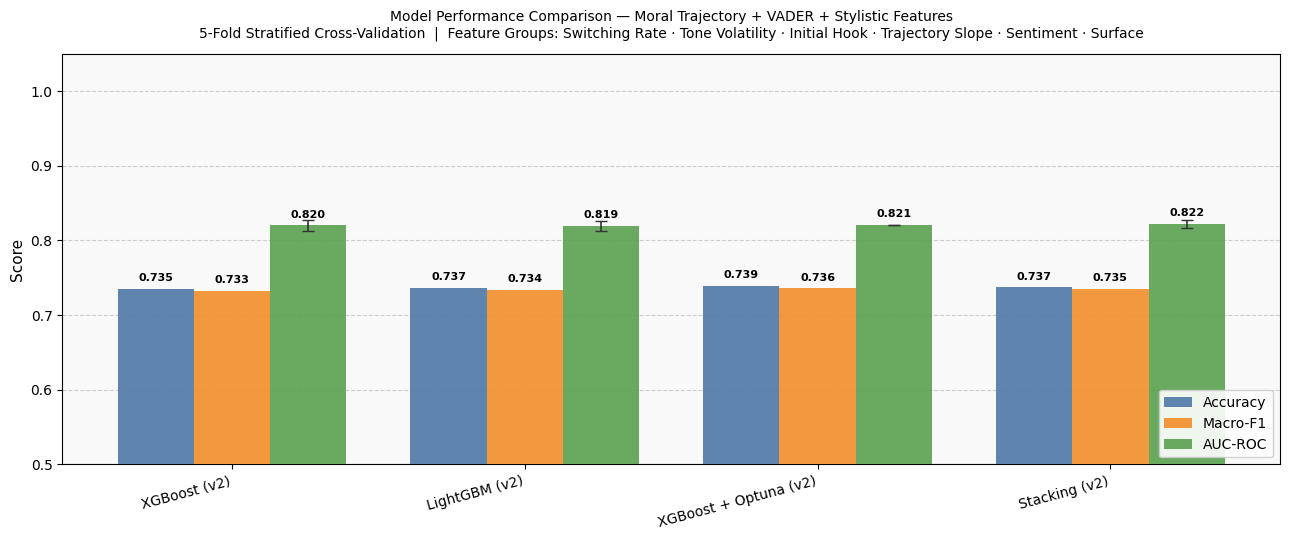

Saved: model_comparison_v2.png


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# PHASE 4A — MODEL COMPARISON TABLE & CHART
# ─────────────────────────────────────────────────────────────────────────────

# ── Console summary ────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  FINAL MODEL COMPARISON  —  Expanded Feature Set")
print("=" * 65)
print(f"  {'Model':<30} {'Acc':>7} {'Macro-F1':>10} {'AUC':>8}")
print("  " + "─" * 57)
for r in results_v2:
    print(f"  {r['label']:<30} {r['acc']:>7.3f}  {r['f1']:>9.3f}  {r['auc']:>7.3f}")
print("=" * 65)

# ── Publication-ready bar chart ─────────────────────────────────────────────
PALETTE = {
    "Accuracy" : "#4E79A7",
    "Macro-F1" : "#F28E2B",
    "AUC-ROC"  : "#59A14F",
}

labels   = [r["label"] for r in results_v2]
accs     = [r["acc"]   for r in results_v2]
f1s      = [r["f1"]    for r in results_v2]
aucs     = [r["auc"]   for r in results_v2]
auc_stds = [r["auc_std"] for r in results_v2]

x = np.arange(len(labels))
w = 0.26

fig, ax = plt.subplots(figsize=(13, 5.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F9F9F9")

b1 = ax.bar(x - w, accs, w, label="Accuracy", color=PALETTE["Accuracy"], alpha=0.90, zorder=3)
b2 = ax.bar(x,     f1s,  w, label="Macro-F1", color=PALETTE["Macro-F1"], alpha=0.90, zorder=3)
b3 = ax.bar(x + w, aucs, w, label="AUC-ROC",  color=PALETTE["AUC-ROC"],  alpha=0.90, zorder=3,
            yerr=auc_stds, capsize=4, error_kw=dict(elinewidth=1.2, ecolor="#333"))

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=10)
ax.set_ylim(0.50, 1.05)
ax.set_ylabel("Score", fontsize=11)
ax.set_title(
    "Model Performance Comparison — Moral Trajectory + VADER + Stylistic Features\n"
    "5-Fold Stratified Cross-Validation  |  Feature Groups: Switching Rate · Tone Volatility · "
    "Initial Hook · Trajectory Slope · Sentiment · Surface",
    fontsize=10, pad=12
)
ax.yaxis.grid(True, linestyle="--", alpha=0.6, zorder=0)
ax.set_axisbelow(True)
ax.legend(loc="lower right", fontsize=10, framealpha=0.9)

# Value labels on bars
for bar_group in [b1, b2, b3]:
    for bar in bar_group:
        h = bar.get_height()
        ax.annotate(
            f"{h:.3f}",
            xy     = (bar.get_x() + bar.get_width() / 2, h),
            xytext = (0, 4), textcoords="offset points",
            ha="center", va="bottom", fontsize=8, fontweight="bold"
        )

plt.tight_layout()
plt.savefig("model_comparison_v2.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: model_comparison_v2.png")

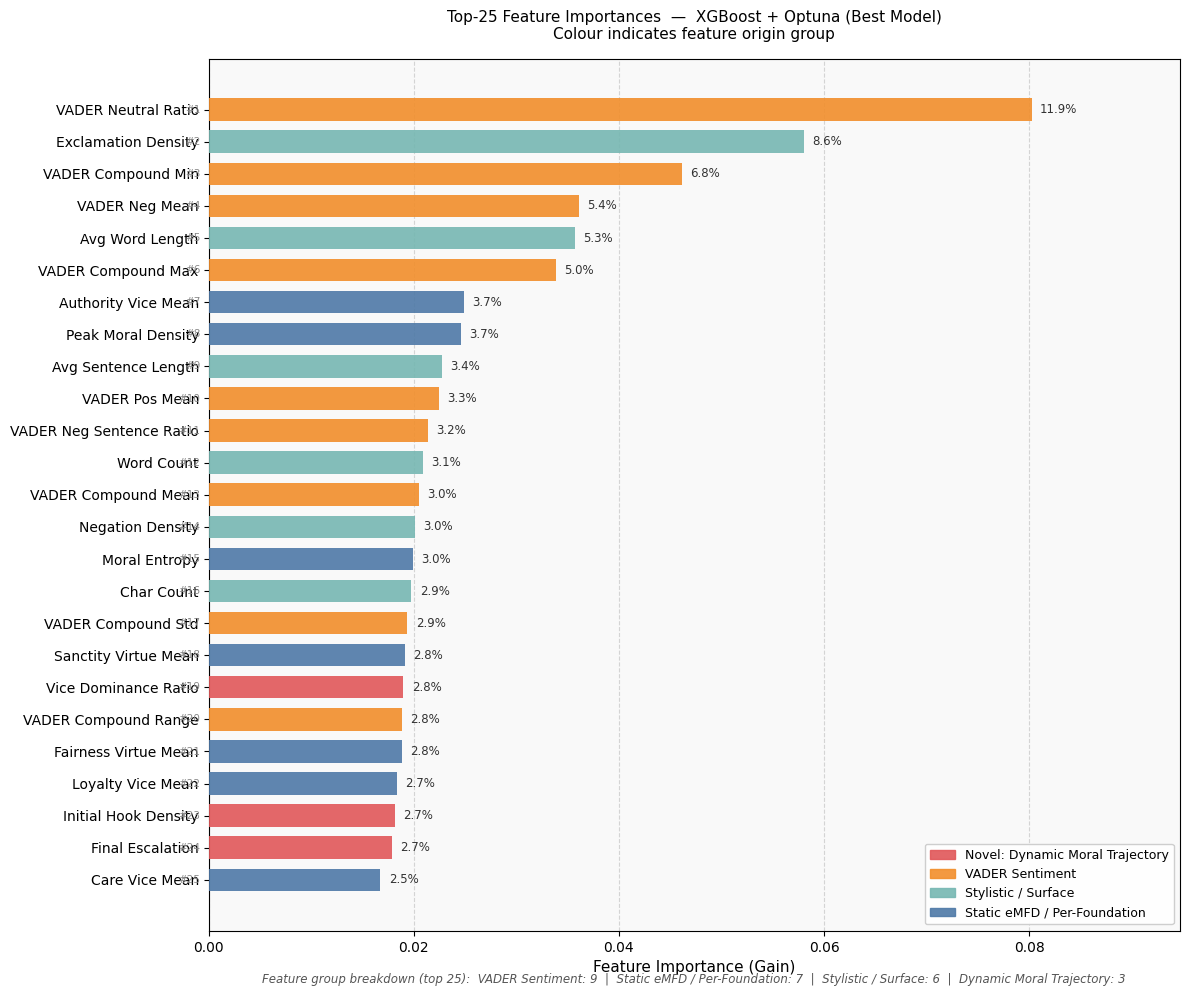

Saved: feature_importance_v2.png

 Rank                    Label                           Group  Importance  Importance_pct
    1      VADER Neutral Ratio                 VADER Sentiment    0.080260           11.91
    2      Exclamation Density             Stylistic / Surface    0.058052            8.61
    3       VADER Compound Min                 VADER Sentiment    0.046173            6.85
    4           VADER Neg Mean                 VADER Sentiment    0.036146            5.36
    5          Avg Word Length             Stylistic / Surface    0.035689            5.30
    6       VADER Compound Max                 VADER Sentiment    0.033908            5.03
    7      Authority Vice Mean    Static eMFD / Per-Foundation    0.024918            3.70
    8       Peak Moral Density    Static eMFD / Per-Foundation    0.024600            3.65
    9      Avg Sentence Length             Stylistic / Surface    0.022732            3.37
   10           VADER Pos Mean                 VADER Sen

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# PHASE 4B — TOP-25 FEATURE IMPORTANCE (Publication-Ready)
# ─────────────────────────────────────────────────────────────────────────────

# Refit best model on full training data
best_xgb2.fit(X, y)

imp_df = pd.DataFrame({
    "Feature"   : feature_cols_v2,
    "Importance": best_xgb2.feature_importances_
}).sort_values("Importance", ascending=False).head(25).reset_index(drop=True)
imp_df["Rank"] = imp_df.index + 1

# Feature group classification
NOVELTY = {
    "switching_rate", "tone_volatility", "initial_hook_density",
    "instability_index", "trajectory_slope", "escalation_delta",
    "final_escalation", "vice_dominance_ratio", "vice_virtue_ratio_volatility"
}
VADER_F = set(vader_features.columns)
STYLE_F = set(style_features.columns)

GROUP_COLORS = {
    "Novel: Dynamic Moral Trajectory": "#E15759",
    "VADER Sentiment"                : "#F28E2B",
    "Stylistic / Surface"            : "#76B7B2",
    "Static eMFD / Per-Foundation"   : "#4E79A7",
}

def classify_feature(f):
    if f in NOVELTY: return "Novel: Dynamic Moral Trajectory"
    if f in VADER_F: return "VADER Sentiment"
    if f in STYLE_F: return "Stylistic / Surface"
    return "Static eMFD / Per-Foundation"

imp_df["Group"]  = imp_df["Feature"].apply(classify_feature)
imp_df["Color"]  = imp_df["Group"].map({k: v for k, v in GROUP_COLORS.items()})
imp_df["Importance_pct"] = (imp_df["Importance"] / imp_df["Importance"].sum() * 100).round(2)

# ── Clean display labels ────────────────────────────────────────────────────
LABEL_MAP = {
    "switching_rate"              : "Switching Rate",
    "tone_volatility"             : "Tone Volatility",
    "initial_hook_density"        : "Initial Hook Density",
    "instability_index"           : "Instability Index",
    "trajectory_slope"            : "Trajectory Slope",
    "escalation_delta"            : "Escalation Delta",
    "final_escalation"            : "Final Escalation",
    "vice_dominance_ratio"        : "Vice Dominance Ratio",
    "vice_virtue_ratio_volatility": "Vice/Virtue Ratio Volatility",
    "vader_compound_mean"         : "VADER Compound Mean",
    "vader_compound_std"          : "VADER Compound Std",
    "vader_compound_range"        : "VADER Compound Range",
    "vader_neg_mean"              : "VADER Neg Mean",
    "vader_pos_mean"              : "VADER Pos Mean",
    "vader_neg_sent_ratio"        : "VADER Neg Sentence Ratio",
    "vader_pos_sent_ratio"        : "VADER Pos Sentence Ratio",
    "vader_neutral_ratio"         : "VADER Neutral Ratio",
    "vader_compound_max"          : "VADER Compound Max",
    "vader_compound_min"          : "VADER Compound Min",
    "exclamation_density"         : "Exclamation Density",
    "caps_ratio"                  : "ALL-CAPS Ratio",
    "negation_density"            : "Negation Density",
    "type_token_ratio"            : "Type-Token Ratio",
    "avg_word_length"             : "Avg Word Length",
    "avg_sentence_length"         : "Avg Sentence Length",
    "avg_moral_density"           : "Avg Moral Density",
    "peak_moral_density"          : "Peak Moral Density",
    "moral_entropy"               : "Moral Entropy",
    "peak_avg_ratio"              : "Peak-to-Average Ratio",
}
imp_df["Label"] = imp_df["Feature"].apply(lambda f: LABEL_MAP.get(f, f.replace("_", " ").title()))

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F9F9F9")

bars = ax.barh(
    imp_df["Label"][::-1],
    imp_df["Importance"][::-1],
    color  = imp_df["Color"][::-1].tolist(),
    alpha  = 0.90,
    height = 0.70,
    zorder = 3
)

# Value annotations (importance % of total)
for bar, (_, row) in zip(bars, imp_df[::-1].iterrows()):
    w_val = bar.get_width()
    ax.text(
        w_val + imp_df["Importance"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{row['Importance_pct']:.1f}%",
        va="center", ha="left", fontsize=8.5, color="#333333"
    )

# Rank labels on y-axis (subtle)
for i, (_, row) in enumerate(imp_df[::-1].iterrows()):
    ax.text(
        -imp_df["Importance"].max() * 0.01,
        i,
        f"#{row['Rank']}",
        va="center", ha="right", fontsize=7.5, color="#888888"
    )

ax.xaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.set_xlabel("Feature Importance (Gain)", fontsize=11)
ax.set_title(
    "Top-25 Feature Importances  —  XGBoost + Optuna (Best Model)\n"
    "Colour indicates feature origin group",
    fontsize=11, pad=14
)
ax.set_xlim(right=imp_df["Importance"].max() * 1.18)

# Legend
legend_handles = [
    mpatches.Patch(color=c, label=g, alpha=0.90)
    for g, c in GROUP_COLORS.items()
]
ax.legend(
    handles=legend_handles, loc="lower right",
    fontsize=9, framealpha=0.95, edgecolor="#CCCCCC"
)

# Group count summary in subtitle area
group_counts = imp_df["Group"].value_counts()
summary = "  |  ".join(f"{g.split(':')[-1].strip()}: {n}" for g, n in group_counts.items())
ax.annotate(
    f"Feature group breakdown (top 25):  {summary}",
    xy=(0.5, -0.06), xycoords="axes fraction",
    ha="center", fontsize=8.5, color="#555555",
    style="italic"
)

plt.tight_layout()
plt.savefig("feature_importance_v2.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: feature_importance_v2.png")
print()
print(imp_df[["Rank","Label","Group","Importance","Importance_pct"]].to_string(index=False))

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# PHASE 4C — SPEARMAN CORRELATION: Key Features × Label
# ─────────────────────────────────────────────────────────────────────────────
from scipy.stats import spearmanr

check_feats = list(NOVELTY) + list(VADER_F)[:5] + list(STYLE_F)[:4]
rows = []
for feat in check_feats:
    if feat in fd.columns:
        rho, pval = spearmanr(fd[feat], fd["label"])
        rows.append({
            "Feature" : feat,
            "Label"   : LABEL_MAP.get(feat, feat.replace("_", " ").title()),
            "rho"     : round(rho, 4),
            "p-value" : round(pval, 6),
            "Group"   : classify_feature(feat)
        })

corr_df = pd.DataFrame(rows).sort_values("rho", key=abs, ascending=False)

print("── Spearman Correlation: Key Features × Binary Label ──────────────")
print(corr_df[["Label","Group","rho","p-value"]].to_string(index=False))

── Spearman Correlation: Key Features × Binary Label ──────────────
                       Label                           Group     rho  p-value
             Avg Word Length             Stylistic / Surface -0.2219 0.000000
        VADER Compound Range                 VADER Sentiment  0.1893 0.000000
             Tone Volatility Novel: Dynamic Moral Trajectory  0.1713 0.000000
           Instability Index Novel: Dynamic Moral Trajectory  0.1710 0.000000
Vice/Virtue Ratio Volatility Novel: Dynamic Moral Trajectory  0.1696 0.000000
         Exclamation Density             Stylistic / Surface  0.1675 0.000000
              Switching Rate Novel: Dynamic Moral Trajectory  0.1593 0.000000
            Final Escalation Novel: Dynamic Moral Trajectory  0.1125 0.000000
        Initial Hook Density Novel: Dynamic Moral Trajectory  0.1116 0.000000
         VADER Neutral Ratio                 VADER Sentiment -0.1075 0.000000
          VADER Compound Min                 VADER Sentiment -0.0974 0.000